# Transition Dynamics and the Boppart-Krusell-Mitman (BKM) Algorithm

Up to this point, our focus has been limited to the analysis of Stationary Equilibrium in heterogeneous agent models. However, many important economic questions require moving beyond the steady-state framework and understanding how the economy evolves over time. This includes studying transition dynamics and analyzing the role of aggregate uncertainty.

Why Go Beyond the Steady State?

In many contexts, it’s crucial to examine how an economy responds to changes over time. For instance:
- How does the economy adjusts to Aggregate shocks (such as productivity or TFP shocks)?
- Policy reforms or structural changes invite the question(s): how long does it take for the economy to converge to a new steady state? How does welfare change?
- More broadly, does household heterogeneity matter for the dynamics of business cycles?

To tackle these questions, we must move away from the simplifying assumption of a stationary equilibrium.

**From Recursive to Sequence Form**

In the baseline models without aggregate shocks, where only idiosyncratic risk is present, the household problem can be expressed recursively. This allows us to derive policy functions that map states into optimal choices.

However, when aggregate shocks—such as TFP changes—are introduced, the economy’s state space becomes infinite-dimensional. This is because the distribution of individual agents across states (assets, income, etc.) becomes a relevant state variable. In such cases, it becomes more convenient to express the household problem in sequence form: agents make decisions at each point in time based on the full history of realized shocks and the anticipated future path of aggregate variables.

**Transition Dynamics and MIT Shocks**

One useful approach to studying transitions is through "MIT" shocks. Here, the economy experiences an unanticipated but transitory change, such as a sudden shift in TFP. After the shock, all agents perfectly foresee the future path of the economy. We can then compute the transition path: a sequence of time-varying aggregate quantities and prices (such as wages and interest rates) that connect the old and new stationary equilibria.

In the sequence form under an MIT shock setting, all dynamics are deterministic, as the entire future path of aggregate variables—such as prices and productivity—is known following the initial unanticipated shock. As a result, there is no need to track the distribution of agents as a separate state variable. Instead, the evolution of time alone serves as a sufficient statistic for characterizing the transition.

**The Role of the Boppart-Krusell-Mitman (BKM) Algorithm**

To compute these transitions, the Boppart-Krusell-Mitman (BKM) algorithm provides a simple numerical approach. It leverages the structure of perfect foresight transitions and linearity of the problem to obtain time-varying dynamics in the presence of household heterogeneity.

## Heterogeneous-Agent Economy with Aggregate Shocks

We consider a heterogeneous-agent economy in which households make optimal intertemporal decisions regarding consumption and asset holdings. Each household maximizes expected lifetime utility by solving the following dynamic programming problem:

$$
V(k, z; K, Z) = \max_{c, k’} \left\{ u(c) + \beta \sum_{z’} \Pi(z’|z) V(k’, z’; K’, Z’) \right\}
$$

subject to the constraints:

$$
\begin{aligned}
c_t + k_{t+1} &\leq (1 + r_t)k_t + w_t z_t \\
c_t &\geq 0 \\
k_t &\geq 0
\end{aligned}
$$

Here, $k$ denotes asset/capital holdings, $z$ is an idiosyncratic labor productivity shock, $K$ is the aggregate capital stock, and $Z$ is the aggregate total factor productivity (TFP). Households face idiosyncratic income risk governed by the Markov transition matrix $\Pi(z’|z)$, and take aggregate prices—wages $w_t$ and interest rates $r_t$—as given.

### Firms and Production

On the production side, firms operate a constant-returns-to-scale production function of the Cobb-Douglas form:

$$
Y_t = F(Z_t, K_t, N) = Z_t K_t^\alpha N^{1-\alpha}
$$

Profit-maximizing firms choose input levels such that factor prices equal marginal products:

$$
\begin{aligned}
w_t &= F_N(Z_t, K_t, N) = (1 - \alpha) Z_t K_t^\alpha N^{-\alpha} \\
r_t &= F_K(Z_t, K_t, N) - \delta = \alpha Z_t K_t^{\alpha - 1} N^{1 - \alpha} - \delta
\end{aligned}
$$

where $\delta$ is the depreciation rate of capital.

### Aggregation and Law of Motion for Distribution

Aggregate capital $K_t$ is obtained by integrating individual policy functions over the current distribution of households:

$$
K_t = \int g_t(k, z) \, d\Phi_t(k, z)
$$

Here, $g_t(k, z)$ is the policy function mapping individual states into optimal asset holdings, and $\Phi_t(k, z)$ is the distribution of agents over individual states at time $t$. The evolution of this distribution follows:

$$
\Phi_{t+1}(k’, z’) = \int \Phi_t(k, z) \cdot \Gamma(k’, z’|k, z) \, dk \, dz
$$

where $\Gamma$ is a transition matrix incorporating both policy functions and the stochastic process for idiosyncratic productivity.

### Aggregate Uncertainty: TFP Shocks

Unlike earlier models that assumed a stationary environment, we now introduce aggregate uncertainty through time-varying TFP. Specifically, the aggregate productivity process $Z_t$ evolves according to a first-order autoregressive (AR(1)) process:

$Z_t = \rho^Z Z_{t-1} + \sigma^Z \varepsilon_t^Z$

where $\rho^Z \in (0,1)$ governs the persistence of the shock, $\sigma^Z$ is the volatility, and $\varepsilon_t^Z \sim \mathcal{N}(0,1)$ represents an i.i.d. innovation.

### Implications

The introduction of stochastic $Z_t$ increases the dimensionality of the problem because the full distribution $\Phi_t$ over agents now becomes an aggregate state variable.

In [1]:
# Solve Krusell-Smith model using MIT shock solution approach (i.e. Transitions)

using Setfield, PrettyTables, Parameters, Roots, Plots, Statistics

include("Functions/VFI_update_spline.jl")
include("Functions/K_agg.jl")
include("Functions/Young.jl")
include("Functions/Tauchen.jl")

## 1. Define parameters
@with_kw struct NumericalParameters
    nk = 100 # Number of points on the capital grid
    nz = 3 # Number of points on the employment grid
    crit = 1.0e-5 # Precision up to which to solve the value function
    maxk = 50 # highest point on the capital grid
    mink = 0 # lowest point on the capital grid
end
n_par = NumericalParameters()

@with_kw struct EconomicParameters
    r = 0 # Real Rate
    ξ = 2 # Coefficient of relative risk aversion
    β = 0.95 # Discount factor
    α = 0.33 # Curvature of production function
    δ = 0.05 # Depreciation
    ρ = 0.9 # persistence of idiosyncratic productivity shock
    ρ_Z = 0.75 # persistence of aggregate productivity (TFP) shock
    b = n_par.mink # borrowing limit
    N = 1 # aggregate labor supply for productivity h
    σ_Z = 0.01 # Std. dev. of TFP shock
end
m_par = EconomicParameters()

## Produce grids
grid_z, Π, bounds = Tauchen(m_par.ρ,n_par.nz)
grid_z = exp.(grid_z)

struct Grids
    k # capital
    z # income
end
gri   = Grids(
            exp.(collect(range(log(1),log(n_par.maxk-n_par.mink+1);length = n_par.nk))) .- 1 .+ n_par.mink, # individual capital grid
            grid_z
        )

# Meshes of capital and productivity
meshes = (
            k = [k for k in gri.k, z in gri.z],
            z = [z for k in gri.k, z in gri.z]
         )

# Define marginal utility and inverse marginal utility
if m_par.ξ == 1.0
    util(c)     = log.(c) # Utility
    mutil(c)    = 1.0 ./c  # Marginal utility
    invmutil(mu) = 1.0 ./mu # inverse marginal utility
else
    util(c)      = 1.0/(1.0 - m_par.ξ) .* c .^(1-m_par.ξ) # Utility
    global mutil(c)     = 1.0 ./(c .^m_par.ξ) # Marginal utility
    global invmutil(mu) = 1.0 ./(mu .^(1.0 ./m_par.ξ)) # inverse marginal utility
end

## Display Model Parameters
pretty_table(
             hcat([
                 "Discount Factor";
                 "Returns to Scale";
                 "Relative Risk Aversion";
                 "Depreciation";
                 "Persistence of TFP shock";
                 "Borrowing limit";
                 "Std. dev. of TFP shock";
              ],
              [
                  m_par.β; m_par.α; m_par.ξ; m_par.δ; m_par.ρ_Z; m_par.b; m_par.σ_Z;
              ])
            )

┌──────────────────────────┬────────┐
│                   Col. 1 │ Col. 2 │
├──────────────────────────┼────────┤
│          Discount Factor │   0.95 │
│         Returns to Scale │   0.33 │
│   Relative Risk Aversion │    2.0 │
│             Depreciation │   0.05 │
│ Persistence of TFP shock │   0.75 │
│          Borrowing limit │    0.0 │
│   Std. dev. of TFP shock │   0.01 │
└──────────────────────────┴────────┘


## Step 1: Set Up — Solving the Steady-State Model without Aggregate Uncertainty

As a starting point, we consider the version of the model without aggregate uncertainty, which corresponds to the stationary equilibrium case studied in previous tutorials. In this setting, there are no aggregate shocks—that is, the aggregate productivity level $Z$ is constant over time—and households only face idiosyncratic income risk.

In [2]:
Kdemand(R)      = m_par.N * (m_par.α/(R+m_par.δ)).^(1/(1-m_par.α))         # Calculate capital demand by firms for a given interest rate and employment
rate(K)         = m_par.α* m_par.N.^(1-m_par.α) .* K.^(m_par.α-1) .-m_par.δ # Calculate the return on capital given K and employment N 
wage(K)         = (1-m_par.α)* m_par.N.^(-m_par.α) .* K.^(m_par.α)          # Calculate the wage rate given K and employment N 
ExcessDemand(K) = K_Agg(rate(K),wage(K),util,n_par,m_par,Π,meshes,gri)[1] - K   # Calculate the difference between capital supply and demand for wages and returns given by assumed capital demand

Rstar           = rate(find_zero(ExcessDemand,(Kdemand(0.05),Kdemand(-0.02)), Roots.Brent(), atol = 1e-5)) # find equilibrium amount of capital (and corresponding rate)
# Rstar = 0.04844574684477476
Kstar           = Kdemand(Rstar)

~,saving_star,marginal_k, StDist, Γ, V = K_Agg(rate(Kstar),wage(Kstar),util,n_par,m_par,Π,meshes,gri)
c_star = meshes.z .* wage(Kstar) .+ meshes.k .* (1+Rstar) .- saving_star

100×3 Matrix{Float64}:
 0.523779  1.12622  2.10025
 0.564674  1.13481  2.10435
 0.594403  1.14427  2.10854
 0.617926  1.15403  2.11292
 0.64028   1.16353  2.1175
 0.660003  1.17342  2.12208
 0.676101  1.18221  2.12682
 0.69475   1.19153  2.13181
 0.712105  1.20115  2.13694
 0.726934  1.2115   2.14215
 ⋮                  
 3.38435   3.70152  4.22659
 3.45937   3.77516  4.29594
 3.53649   3.85089  4.36747
 3.61578   3.92879  4.44129
 3.69731   4.00892  4.51768
 3.78117   4.09136  4.59718
 3.86742   4.17617  4.68174
 3.95617   4.26386  4.78798
 4.04776   4.35673  5.11099

Now, choose a time $T$ at which we assume the economy is back at steady state (or has reached a new steady state).

In [3]:
T = 100

100

Finally, let's generate a path for the aggregate shock. In this case, we are considering a TFP shock but this could be any shock(s).

In [4]:
ZT = log.(ones(T,1))
ε = zeros(T,1)
ε[2] = m_par.σ_Z

for i = 2:T
    ZT[i] = m_par.ρ_Z * ZT[i-1] + m_par.σ_Z * ε[i]
end
ZT = exp.(ZT)

100×1 Matrix{Float64}:
 1.0
 1.0001000050001667
 1.0000750028125702
 1.000056251582061
 1.000042188389905
 1.0000316411255699
 1.0000237307503197
 1.0000177980099452
 1.000013348477762
 1.000010011341617
 ⋮
 1.0000000000000007
 1.0000000000000004
 1.0000000000000002
 1.0000000000000002
 1.0000000000000002
 1.0000000000000002
 1.0
 1.0
 1.0

## Step 2: Guess capital path

In [5]:
# Heroic guess for the initial path of {K_t}: K_t = K* for all t
KT = []
push!(KT, repeat([Kstar], T))

VPT = repeat(V,outer=(1,1,T))            # Guess for the value function in each period
SPT = repeat(saving_star,outer=(1,1,T))  # Guess for the savings policy functions in each period
CPT = repeat(c_star,outer=(1,1,T))       # Guess for the consumption policy function in each period
DIST = repeat(StDist,outer=(1,T))        # Guess for the distribution in each period

300×100 Matrix{Float64}:
 0.0241903    0.0241903    0.0241903    …  0.0241903    0.0241903
 0.00348923   0.00348923   0.00348923      0.00348923   0.00348923
 0.00284398   0.00284398   0.00284398      0.00284398   0.00284398
 0.00270078   0.00270078   0.00270078      0.00270078   0.00270078
 0.00199528   0.00199528   0.00199528      0.00199528   0.00199528
 0.00246104   0.00246104   0.00246104   …  0.00246104   0.00246104
 0.00266965   0.00266965   0.00266965      0.00266965   0.00266965
 0.00225744   0.00225744   0.00225744      0.00225744   0.00225744
 0.00186253   0.00186253   0.00186253      0.00186253   0.00186253
 0.00306966   0.00306966   0.00306966      0.00306966   0.00306966
 ⋮                                      ⋱               
 0.00426088   0.00426088   0.00426088      0.00426088   0.00426088
 0.00342298   0.00342298   0.00342298      0.00342298   0.00342298
 0.00264584   0.00264584   0.00264584      0.00264584   0.00264584
 0.00195438   0.00195438   0.00195438      0.001

## Step 3: Backward iteration

Once we have a guess for capital $(\{K_t\}_{t=1}^{T-1})^0$, we can solve for the sequence of prices $\{r_t\}_{t=1}^{T-1}$ and $\{w_t\}_{t=1}^{T-1}$, using the firm's FOCs. Then, given prices we can solve the households' problem and obtain an update of the policy functions.

Since, we assume that at $t=T$, the economy is back at the steady state (or has reached a new steady state) computed in step 1, we can compute this for $t = T-1$, and then repeat until $t=1$ when the shock takes place.

In [6]:
iter_bkm = 1 # BKM algorith requires iteration until convergence. However, for the moment we just look at the first iteration

T = length(ZT)

rT         = ZT .* m_par.α .* m_par.N.^(1-m_par.α) .* KT[iter_bkm].^(m_par.α-1) .-m_par.δ
wT         = ZT .* (1-m_par.α) .* m_par.N.^(-m_par.α) .* KT[iter_bkm].^(m_par.α) 

# Start from the steady-state and iterate backwards
for h = 1:(T-2)
    t = T - h
    
    # Current period interest rate and wage
    r = rT[t]
    w = wT[t]
    
    # Update Policy
    CashPT = meshes.z*w + meshes.k*(1+r) # Cash at hand (Labor income plus assets cumulative dividend) with r = rT[t] and w = wT[t]
    VPT[:,:,t], SPT[:,:,t] = VFI_update_spline(VPT[:,:,t+1],CashPT,util,m_par,n_par,gri,Π)
    CPT[:,:,t] = meshes.z .* w .+ meshes.k .* (1+r) .- SPT[:,:,t]
    
end

## Step 4: Forward iteration

At period $t=0$, the economy is still at steady state since the shock has not yet taken place. Hence, we know the policy function and distribution in this period.

Using the law of motion for the distribution we can update for $\Phi$. Combined with the sequences for prices and policy functions obtained in step 3, we can aggregate the individual asset holdings and obtain an update for path of aggregate capital.

In [7]:
T = size(SPT,3)
KTUpdate = zeros(T)
KTUpdate[1] = Kstar

for t=2:T
    Γ, StDist = Young(SPT[:,:,t-1],gri,n_par,Π)
    DIST[:,t] = DIST[:,t-1]'*Γ
    KTUpdate[t] = dot(sum(reshape(DIST[:,t],n_par.nk,n_par.nz),dims=2),gri.k)
end

## Step 5: Checking convergence

Finally, we check if the difference between the previous iteration capital sequence and the current iteration is small enough. If this is the case, then the algorithm has converged and we have found a solution.

In [8]:
diff = maximum(abs.(KTUpdate-KT[iter_bkm]))

0.0007089215863516074

The result of `diff` is larger than the convergence critical value we have specified in numerical parameters. Hence, we would have to repeat steps 3-5 again and obtain a new update for the capital sequence.

## Putting everything together

In [9]:
# Generate a function that computes the backward step
function backward_update(KT_guess, ZT, VPT, SPT, CPT, util, m_par, n_par, gri, meshes, Π)
    
    T = length(ZT)

    rT         = ZT .* m_par.α .* m_par.N.^(1-m_par.α) .* KT_guess.^(m_par.α-1) .-m_par.δ
    wT         = ZT .* (1-m_par.α) .* m_par.N.^(-m_par.α) .* KT_guess.^(m_par.α) 

    # Start from the steady-state and iterate backwards
    for h = 1:(T-2)
        t = T - h
        
        # Current period interest rate and wage
        r = rT[t]
        w = wT[t]
        
        # Update Policy
        CashPT = meshes.z*w + meshes.k*(1+r) # Cash at hand (Labor income plus assets cumulative dividend) with r = rT[t] and w = wT[t]
        VPT[:,:,t], SPT[:,:,t] = VFI_update_spline(VPT[:,:,t+1],CashPT,util,m_par,n_par,gri,Π)
        CPT[:,:,t] = meshes.z .* w .+ meshes.k .* (1+r) .- SPT[:,:,t]
        
    end

    return VPT, SPT, CPT
end

# Generate a function that computes the forward step
function forward_update(Kstar,SPT,DIST,gri,n_par,Π)

    T = size(SPT,3)
    KT_forward = zeros(T)
    KT_forward[1] = Kstar

    for t=2:T
        Γ, StDist = Young(SPT[:,:,t-1],gri,n_par,Π)
        DIST[:,t] = DIST[:,t-1]'*Γ
        KT_forward[t] = dot(sum(reshape(DIST[:,t],n_par.nk,n_par.nz),dims=2),gri.k)
    end

    return DIST, KT_forward
end

# Implementation of all the BKM steps in one function.
function solve_bkm!(Kstar,KT,ZT,VPT,SPT,CPT,DIST,util,m_par,n_par,gri,meshes,Π; convex_combination::Float64 = 0.2,
    shrink_factor::Float64 = 0.5, expand_factor::Float64 = 1.05,
    maxiter_bkm::Int64 = 1000, tol::Float64=1e-6, verbose::Bool=true, display_iter::Int64 = 20)


    T = length(ZT)

    # Initializations
    diff = 10e10
    diff_old = 10e10
    convergence_flag = 0
    damp = convex_combination
    # stop_crit = 1.0e-5
    # iter = 0

    # while diffKT > stop_crit
    for iter_bkm = 1:maxiter_bkm
        # Step 1: Backward solving for the policy functions
        VPT, SPT, CPT = backward_update(KT[iter_bkm],ZT,VPT,SPT,CPT,util,m_par,n_par,gri,meshes,Π)

        # Step 2: Forward solving for the distribution and K path
        DIST, KTUpdate = forward_update(Kstar,SPT,DIST,gri,n_par,Π)

        # Step 3: Check convergence
        diff = maximum(abs.(KTUpdate-KT[iter_bkm]))

        # Display every display_iter iterations
        if verbose==true
            if mod(iter_bkm,display_iter) == 0
                println("Iteration $(iter_bkm). diff = $(diff)")
            end
        end

        if diff < tol
            if verbose==true
                println("Convergence reached after $(iter_bkm) iterations.")
            end
            convergence_flag = 1
            break
        else
            # Update the guess for the path {K_t}
            # Decrease the dampening factor
            if diff > diff_old
                damp = max(min(damp * shrink_factor, 1.0-eps()), eps())
            # Increase the dampening factor
            else
                damp = max(min(damp * expand_factor, 1.0-eps()), eps())
            end
            if mod(iter_bkm, 10) == 0
                if verbose==true
                    println("damp = $(damp); diff = $(diff)")
                end
            end
            # Store the updated path for {K_t}
            push!(KT, damp.*KTUpdate .+ (1.0 - damp).*KT[iter_bkm])
            diff_old = diff
        end


    end

    return KT, convergence_flag

end

solve_bkm! (generic function with 1 method)

In [10]:
# Find the path for {K_t}:
K_path, convergence_flag = solve_bkm!(Kstar,KT,ZT,VPT,SPT,CPT,DIST,util,m_par,n_par,gri,meshes,Π);

damp = 0.3257789253554885; diff = 3.314543694443728e-5
Convergence reached after 17 iterations.


In [11]:
# Find the path for other aggregates:
r_path = zeros(length(ZT)) #to store the interest rate on path
w_path = zeros(length(ZT)) #to store the wage on path
for t=length(ZT):-1:1 #iterate backward
    # Next period
    r_path[t] = ZT[t] .* m_par.α .* m_par.N.^(1-m_par.α) .* K_path[end][t].^(m_par.α-1) .-m_par.δ
    w_path[t] = ZT[t] .* (1-m_par.α) .* m_par.N.^(-m_par.α) .* K_path[end][t].^(m_par.α) 
end

## Results

┌ Info: Saved animation to /Users/albert/Dropbox/0_Teaching/Tuebingen/SoSe 2025/Adv. Macro II/Tutorials/Tutorial 7/K_convergence.gif
└ @ Plots /Users/albert/.julia/packages/Plots/Ec1L1/src/animation.jl:156


Plots.AnimatedGif("/Users/albert/Dropbox/0_Teaching/Tuebingen/SoSe 2025/Adv. Macro II/Tutorials/Tutorial 7/K_convergence.gif")
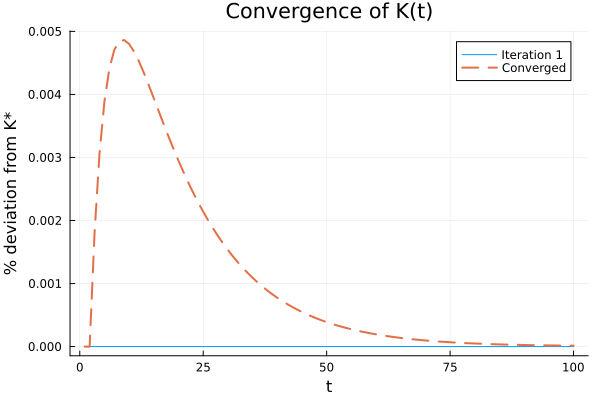

In [12]:
true_K  = K_path[end]        # the converged capital path
anim    = @animate for (n, Kn) in enumerate(K_path)
    # plot the current iterate Kn
    p = plot(1:T,
             log.(Kn ./ Kstar) .* 100,
             label   = "Iteration $n",
             xlabel  = "t",
             ylabel  = "% deviation from K*",
             title   = "Convergence of K(t)",
             legend  = :best)

    # overlay the converged true_K each time
    plot!(p,
          1:T,
          log.(true_K ./ Kstar) .* 100,
          linestyle = :dash,
          lw        = 2,
          label     = "Converged")

    p
end

gif(anim, "K_convergence.gif", fps = 4)

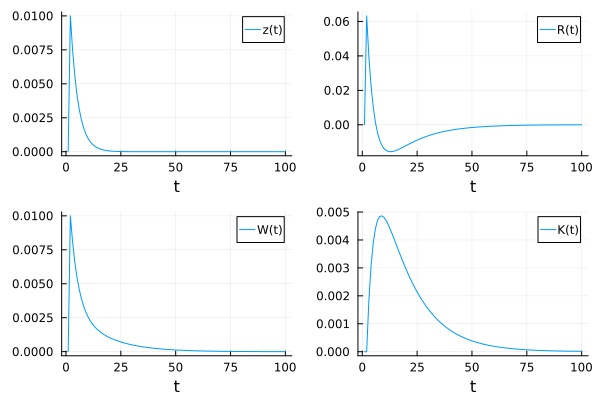

In [13]:
p1 = plot(1:T, log.(ZT./ZT[end]).*100, label = "z(t)", xlabel= "t")
p2 = plot(1:T, log.(r_path./r_path[end]).*100, label= "R(t)", xlabel= "t")
p3 = plot(1:T, log.(w_path./w_path[end]).*100, label= "W(t)", xlabel= "t")
p4 = plot(1:T, log.(K_path[end]./Kstar).*100, label= "K(t)", xlabel= "t" )

p5 = plot(p1, p2, p3, p4)

**Advantages**
- Simple to implement: The method is straightforward and user-friendly, making it accessible for a wide range of applications.
- Flexible with multiple shocks: Adding additional shocks is easy due to linearity—each shock can be simulated individually, and the overall effect is the sum of the impulse responses.

**Disadvantages**
- Limited accuracy in non-linear settings: If the model exhibits strong non-linearities, the linear approximation may perform poorly.
- Potentially slow convergence: Depending on the model’s structure, the algorithm may converge slowly.